# Image compression with k-means (color quantization)

**Solution notebook.** An image is a grid of pixels, and every pixel is a point in **RGB space** --- three numbers. If we cluster the pixels with k-means and repaint each pixel with its cluster's centroid color, the image ends up using only **`k` colors**. That is *color quantization*: lossy compression you can actually see.

Seed is fixed to `509` throughout. Every figure and image produced here is written to the **`out/`** subfolder.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

SEED = 509
np.random.seed(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)   # all results are written here

# Armenian flag colors, for plots with <= 3 series
ARM_RED, ARM_BLUE = "#D90012", "#0033A0"

## 1. Load the image

Before any algorithm runs, count what is actually in the file. **That number is the thing this
whole notebook is trying to shrink** --- and by the end of section 6 we will be describing the
same picture with sixteen colours.


Original size (W x H): (605, 600)  |  pixels: 363,000
distinct colours actually used : 196,680
the 24-bit RGB cube could hold : 16,777,216
colours used by exactly one pixel: 73% of the palette, covering 40% of the image


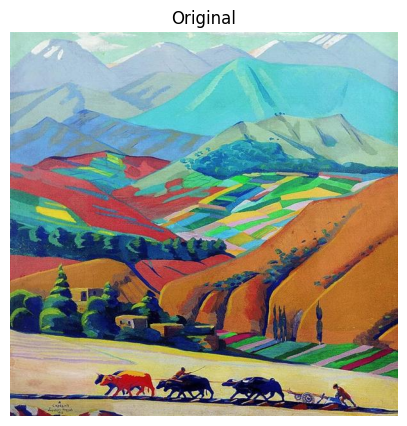

In [2]:
IMG_PATH = "img/saryan_mountains.jpg"

img = Image.open(IMG_PATH).convert("RGB")
flat = np.asarray(img).reshape(-1, 3)
colours, counts = np.unique(flat, axis=0, return_counts=True)
n_px = len(flat)
print(f"Original size (W x H): {img.size}  |  pixels: {n_px:,}")
print(f"distinct colours actually used : {len(colours):,}")
print(f"the 24-bit RGB cube could hold : {256 ** 3:,}")
print(f"colours used by exactly one pixel: {(counts == 1).sum() / len(colours):.0%} of the palette,"
      f" covering {(counts == 1).sum() / n_px:.0%} of the image")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()


## 2. Reshape to points and scale

k-means cost grows with the number of **pixels**, not the file size, so resize large images down first. Then flatten `(H, W, 3)` into `(n_pixels, 3)` and scale to `[0, 1]`.

In [3]:
MAX_WIDTH = 400  # resize for speed; the whole analysis below runs on this size
w, h = img.size
if w > MAX_WIDTH:
    img = img.resize((MAX_WIDTH, int(h * MAX_WIDTH / w)))
    print(f"Resized to (W x H): {img.size}  |  pixels: {img.size[0] * img.size[1]:,}")

arr = np.asarray(img)                                    # (H, W, 3), uint8 in [0, 255]
H, W, C = arr.shape
pixels = arr.reshape(-1, 3).astype(np.float64) / 255.0   # (n_pixels, 3) in [0, 1]

print(f"pixels shape: {pixels.shape}")
print(f"unique colors: {len(np.unique(pixels, axis=0)):,}")

Resized to (W x H): (400, 396)  |  pixels: 158,400
pixels shape: (158400, 3)
unique colors: 124,841


## 3. Quantize with k-means for several `k`

k= 2  inertia=13,863.3


k= 4  inertia=6,081.1


k= 8  inertia=3,196.6


k=16  inertia=1,802.6


k=32  inertia=1,008.9


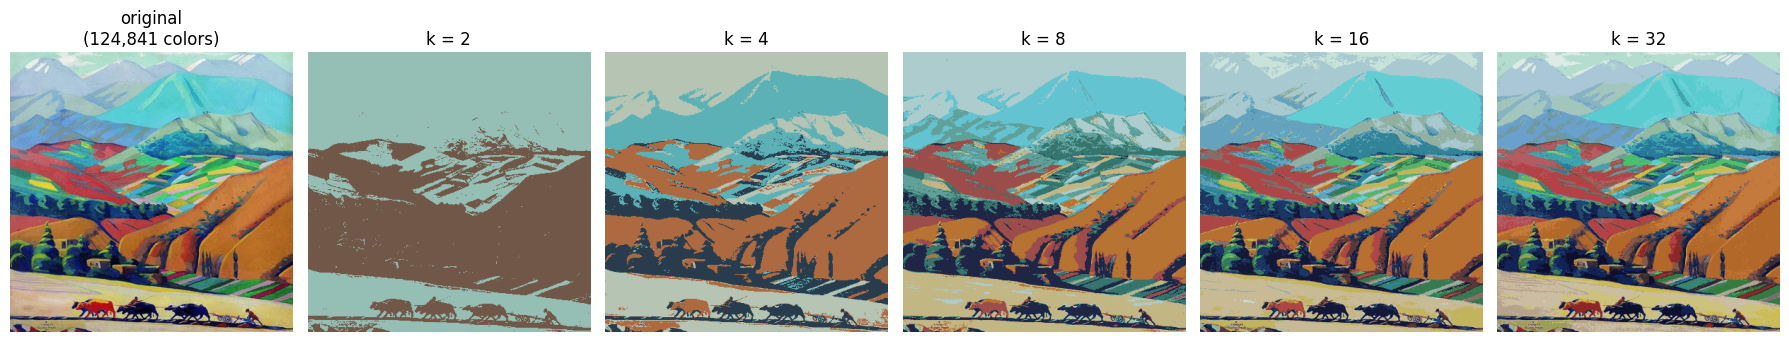

In [4]:
def quantize(pixels, k, shape, seed=SEED):
    # cluster pixels into k colors; return (quantized_image_uint8, fitted_kmeans)
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = km.fit_predict(pixels)
    quant = km.cluster_centers_[labels]                  # repaint each pixel with its centroid color
    quant_img = (quant.reshape(shape) * 255).round().astype(np.uint8)
    return quant_img, km


k_values = [2, 4, 8, 16, 32]
quant_images, kmeans_models = {}, {}

for k in k_values:
    quant_images[k], kmeans_models[k] = quantize(pixels, k, (H, W, C))
    Image.fromarray(quant_images[k]).save(os.path.join(OUT_DIR, f"saryan_k{k:02d}.jpg"), quality=95)
    print(f"k={k:>2}  inertia={kmeans_models[k].inertia_:,.1f}")

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3.5))
axes[0].imshow(arr)
axes[0].set_title(f"original\n({len(np.unique(pixels, axis=0)):,} colors)")
axes[0].axis("off")
for ax, k in zip(axes[1:], k_values):
    ax.imshow(quant_images[k])
    ax.set_title(f"k = {k}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_grid.png"), dpi=120, bbox_inches="tight")
plt.show()

## 4. Pixels live in RGB space

Every pixel is a point with coordinates `(R, G, B)`. k-means groups these points and replaces each one with its group's center. Below: 3000 sampled pixels (faint, each drawn in its own color) and the **8 centroids** k-means chose (large markers). The entire image gets repainted with just those few colors. The plot is **interactive** --- drag to rotate, scroll to zoom.

In [5]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"   # compact mimebundle; Quarto supplies plotly.js

sample = pixels[np.random.choice(len(pixels), 3000, replace=False)]
cents = kmeans_models[8].cluster_centers_

def rgb_str(arr01):
    return [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in arr01]

fig = go.Figure()
fig.add_scatter3d(
    x=sample[:, 0], y=sample[:, 1], z=sample[:, 2], mode="markers",
    marker=dict(size=2.5, color=rgb_str(sample), opacity=0.55), name="pixels",
)
fig.add_scatter3d(
    x=cents[:, 0], y=cents[:, 1], z=cents[:, 2], mode="markers",
    marker=dict(size=10, color=rgb_str(cents), line=dict(color="black", width=2)),
    name="centroids (k=8)",
)
fig.update_layout(
    title="Pixels in RGB space + k=8 centroids (drag to rotate, scroll to zoom)",
    scene=dict(xaxis_title="R", yaxis_title="G", zaxis_title="B"),
    width=720, height=620, margin=dict(l=0, r=0, t=40, b=0),
)
fig.write_html(os.path.join(OUT_DIR, "rgb_scatter.html"), include_plotlyjs="cdn")   # interactive artifact saved to out/
fig.show()

## 5. Choosing `k`

Two standard tools: the **elbow** (inertia keeps dropping --- look for the bend) and the **silhouette** (higher is better). The silhouette is expensive, so we sample pixels and reuse the models we already fit.

> **Honest caveat for this task.** Pixel colors form a *continuum*, not tidy separated clusters, so the silhouette here just **declines** as `k` grows --- it would pick `k = 2`, which is useless for quantization. For this task `k` is a **quality-vs-size trade-off**, not a "true number of clusters" --- pick the smallest `k` whose result still looks good.

k= 2  silhouette=0.458
k= 4  silhouette=0.455
k= 8  silhouette=0.408
k=16  silhouette=0.385
k=32  silhouette=0.351


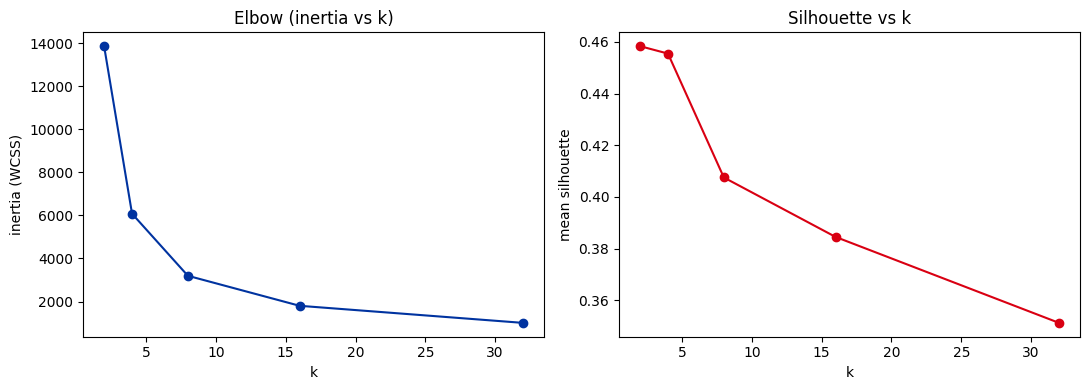

In [6]:
inertias = [kmeans_models[k].inertia_ for k in k_values]
sil_scores = [
    silhouette_score(pixels, kmeans_models[k].labels_, sample_size=3000, random_state=SEED)
    for k in k_values
]
for k, sil in zip(k_values, sil_scores):
    print(f"k={k:>2}  silhouette={sil:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_values, inertias, marker="o", color=ARM_BLUE)
ax[0].set(title="Elbow (inertia vs k)", xlabel="k", ylabel="inertia (WCSS)")
ax[1].plot(k_values, sil_scores, marker="o", color=ARM_RED)
ax[1].set(title="Silhouette vs k", xlabel="k", ylabel="mean silhouette")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "elbow_silhouette.png"), dpi=120)
plt.show()

## 6. The palette --- the `k` centroid colors

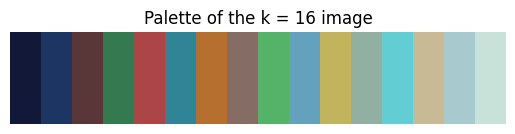

In [7]:
def show_palette(km, title, fname):
    colors = km.cluster_centers_                         # (k, 3) in [0, 1]
    order = np.argsort(colors.sum(axis=1))               # sort dark -> light so the strip reads nicely
    strip = colors[order][np.newaxis, :, :]              # (1, k, 3)
    plt.figure(figsize=(len(colors) * 0.4, 1.2))
    plt.imshow(strip, aspect="auto")
    plt.title(title)
    plt.axis("off")
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=120, bbox_inches="tight")
    plt.show()

show_palette(kmeans_models[16], "Palette of the k = 16 image", "palette_k16.png")

## 7. How much did we compress? (theory)

Measure the information, not a re-saved file.

- **Original:** 3 channels x 8 bits = **24 bits/pixel**.
- **Quantized:** one index per pixel = **`ceil(log2 k)` bits/pixel**, plus a tiny palette of `k x 3` bytes.

So the ratio is roughly `24 / ceil(log2 k)` for a large image. We also report the **reconstruction MSE** --- how far the repainted pixels sit from the originals.

In [8]:
def compression_report(pixels, km, k):
    n = pixels.shape[0]
    index_bits = int(np.ceil(np.log2(k)))                # bits to name one of k colors
    quantized_bits = n * index_bits + k * 3 * 8          # per-pixel indices + the palette
    original_bits = n * 3 * 8                             # 24 bits per pixel
    ratio = original_bits / quantized_bits

    quant = km.cluster_centers_[km.labels_]
    mse = np.mean((pixels - quant) ** 2)                 # in [0, 1] color space

    print(f"k = {k:>2} | {index_bits} bits/px (vs 24) | "
          f"{original_bits/8/1024:6.0f} KB -> {quantized_bits/8/1024:6.0f} KB | "
          f"{ratio:5.1f}x | MSE={mse:.5f} (RMSE ~ {np.sqrt(mse)*255:.1f}/255)")

for k in k_values:
    compression_report(pixels, kmeans_models[k], k)

k =  2 | 1 bits/px (vs 24) |    464 KB ->     19 KB |  24.0x | MSE=0.02917 (RMSE ~ 43.6/255)
k =  4 | 2 bits/px (vs 24) |    464 KB ->     39 KB |  12.0x | MSE=0.01280 (RMSE ~ 28.8/255)
k =  8 | 3 bits/px (vs 24) |    464 KB ->     58 KB |   8.0x | MSE=0.00673 (RMSE ~ 20.9/255)
k = 16 | 4 bits/px (vs 24) |    464 KB ->     77 KB |   6.0x | MSE=0.00379 (RMSE ~ 15.7/255)
k = 32 | 5 bits/px (vs 24) |    464 KB ->     97 KB |   4.8x | MSE=0.00212 (RMSE ~ 11.7/255)


## 8. Real file sizes: indexed PNG

The bits above are theoretical. Here is the real payoff: save each quantized image as an
**indexed (palette) PNG** --- a format that stores one small palette plus one index per pixel,
exactly the scheme we counted. The file genuinely shrinks as `k` drops.


In [9]:
orig_png = os.path.join(OUT_DIR, "original.png")
Image.fromarray(arr).save(orig_png, optimize=True)
orig_size = os.path.getsize(orig_png)
print(f"original as lossless PNG: {orig_size/1024:6.1f} KB\n")

for k in k_values:
    path = os.path.join(OUT_DIR, f"indexed_k{k:02d}.png")
    # build the indexed PNG straight from the k-means result: one palette + one index per pixel
    palette = (kmeans_models[k].cluster_centers_ * 255).round().astype(np.uint8)   # (k, 3) colors
    index_img = kmeans_models[k].labels_.reshape(H, W).astype(np.uint8)            # one index per pixel
    im = Image.frombytes("P", (W, H), index_img.tobytes())
    im.putpalette(list(palette.flatten()))
    im.save(path, optimize=True)
    sz = os.path.getsize(path)
    print(f"k={k:>2}  indexed PNG: {sz/1024:6.1f} KB  ({orig_size/sz:5.1f}x smaller than original PNG)")

original as lossless PNG:  284.0 KB

k= 2  indexed PNG:    3.7 KB  ( 76.0x smaller than original PNG)
k= 4  indexed PNG:    8.9 KB  ( 32.0x smaller than original PNG)
k= 8  indexed PNG:   14.4 KB  ( 19.7x smaller than original PNG)
k=16  indexed PNG:   20.6 KB  ( 13.8x smaller than original PNG)
k=32  indexed PNG:   28.8 KB  (  9.8x smaller than original PNG)


### The same images, measured as JPEG

That table is only true because we chose a format that stores what we actually built. Measure the
identical quantized pixels as **JPEG** instead and see what happens.


In [10]:
import io


def jpeg_bytes(a, quality=90):
    buf = io.BytesIO()
    Image.fromarray(a).save(buf, format="JPEG", quality=quality)
    return buf.getbuffer().nbytes


orig_jpg = jpeg_bytes(arr)
print(f"{'k':>4}  {'indexed PNG':>12}  {'vs orig PNG':>12}   {'JPEG':>9}  {'vs orig JPEG':>13}")
print(f"{'orig':>4}  {orig_size / 1024:9.1f} KB  {'1.0x':>12}   "
      f"{orig_jpg / 1024:6.1f} KB  {'1.000x':>13}")
for k in k_values:
    png_sz = os.path.getsize(os.path.join(OUT_DIR, f"indexed_k{k:02d}.png"))
    jpg_sz = jpeg_bytes((quant_images[k] * 255).round().astype(np.uint8)
                        if quant_images[k].dtype != np.uint8 else quant_images[k])
    flag = "  <-- BIGGER" if jpg_sz > orig_jpg else ""
    print(f"{k:>4}  {png_sz / 1024:9.1f} KB  {orig_size / png_sz:11.1f}x   "
          f"{jpg_sz / 1024:6.1f} KB  {jpg_sz / orig_jpg:12.3f}x{flag}")


   k   indexed PNG   vs orig PNG        JPEG   vs orig JPEG
orig      284.0 KB          1.0x     57.3 KB         1.000x
   2        3.7 KB         76.0x     31.4 KB         0.548x
   4        8.9 KB         32.0x     52.1 KB         0.908x
   8       14.4 KB         19.7x     55.6 KB         0.970x
  16       20.6 KB         13.8x     58.2 KB         1.015x  <-- BIGGER
  32       28.8 KB          9.8x     60.2 KB         1.050x  <-- BIGGER


Same pixels. Same `k`. Two formats, two opposite verdicts --- and at `k = 16` the JPEG is
**larger than the original**, after we threw away 99.99 % of the colours.

JPEG does not store colours. It stores frequencies, via a discrete cosine transform, and it is
tuned for the smooth gradients that photographs are made of. Quantization replaces those gradients
with **hard edges**, and a hard edge is exactly what a cosine basis is worst at: it takes many
high-frequency coefficients to describe a step. So posterizing an image gives JPEG *more* work to
do, not less.

::: {.callout-warning}
## This is not a hypothetical

`archive/2025_image_compression_ml_old.ipynb` is the 2025 version of this practical, and it closes
by reporting a **34.76x** compression ratio from exactly this comparison. The number is an
artifact:

| | bytes | pixels | bytes/pixel |
|---|---|---|---|
| original | 6,443,042 | 24,000,000 | 0.2685 |
| "compressed" to 50 colours | 185,338 | 666,000 | 0.2783 |

The image had been resized from 6000x4000 to 1000x666 before clustering, and **the resize alone
accounts for 36.04x**. Per pixel, the quantization step made the file 3.7 % *bigger* --- the one
operation being taught had negative measured value, hidden behind a headline that looked like a
win.

The lesson is not "JPEG bad". It is that **a compression ratio is a property of the measurement,
not of the algorithm**, and a ratio nobody decomposed is a ratio nobody has checked.
:::


## 9. Where it breaks

At small `k`, smooth gradients (sky, shadows) collapse into a few flat regions --- **banding /
posterization**. That is the visible cost of too few colors.

How badly it shows depends on **the image**, not only on `k`, so it is worth looking at two.


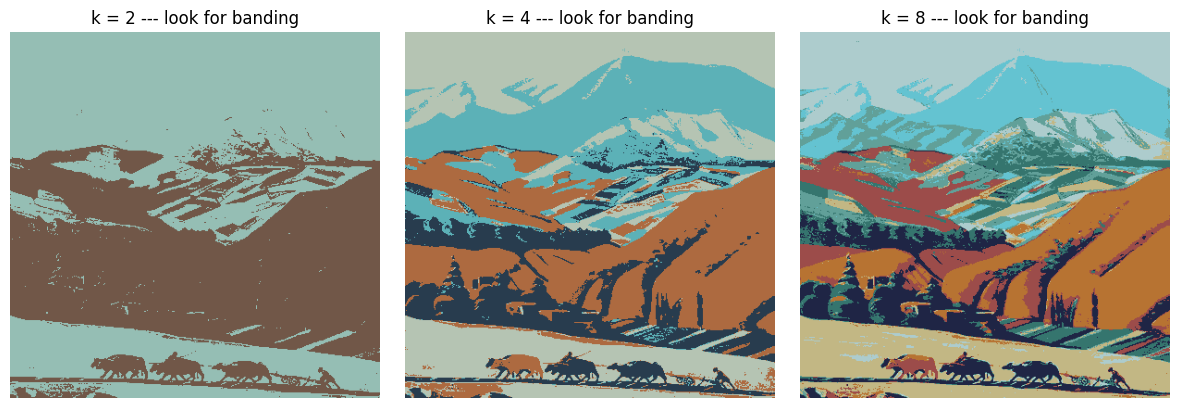

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [2, 4, 8]):
    ax.imshow(quant_images[k])
    ax.set_title(f"k = {k} --- look for banding")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "banding.png"), dpi=120, bbox_inches="tight")
plt.show()

### A second image, because `k` alone does not decide this

The Saryan is a good test of palette *size* but a poor test of banding: it is painted in broad
flat areas of strong colour, so quantizing it is close to what the painting already did. Banding
needs long, slow gradients. Aivazovsky's seascapes are almost nothing but.


image           median neighbour step   near-flat pixels
Saryan                           4.00             23.1%
Aivazovsky                       1.33             60.2%


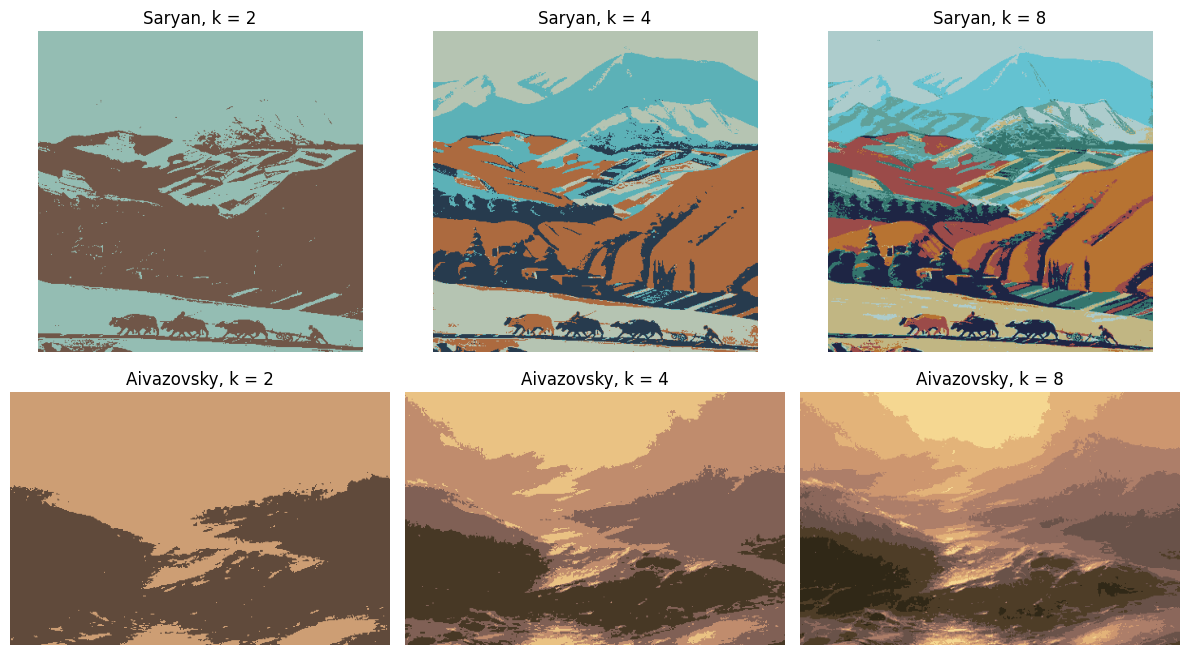

In [12]:
img2 = Image.open("img/aivazovsky.jpg").convert("RGB")
w2, h2 = img2.size
img2 = img2.resize((MAX_WIDTH, int(h2 * MAX_WIDTH / w2)))
arr2 = np.asarray(img2)
H2, W2, _ = arr2.shape
pixels2 = arr2.reshape(-1, 3).astype(np.float64) / 255.0


def smoothness(a):
    """Mean absolute step between horizontally adjacent pixels - low means gradient-heavy."""
    return float(np.median(np.abs(np.diff(a.astype(np.int16), axis=1)).mean(axis=2)))


print(f"{'image':14s} {'median neighbour step':>22s} {'near-flat pixels':>18s}")
for name, a in [("Saryan", arr), ("Aivazovsky", arr2)]:
    g = np.abs(np.diff(a.astype(np.int16), axis=1)).mean(axis=2)
    print(f"{name:14s} {np.median(g):22.2f} {(g < 2).mean():17.1%}")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, (name, source) in enumerate([("Saryan", pixels), ("Aivazovsky", pixels2)]):
    shape = (H, W, 3) if row == 0 else (H2, W2, 3)
    for ax, k in zip(axes[row], [2, 4, 8]):
        km = KMeans(n_clusters=k, n_init=4, random_state=SEED).fit(source)
        ax.imshow(km.cluster_centers_[km.labels_].reshape(shape))
        ax.set_title(f"{name}, k = {k}")
        ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "banding_two_images.png"), dpi=120, bbox_inches="tight")
plt.show()


The numbers say it before the pictures do. Aivazovsky's median step between neighbouring pixels is
about a third of the Saryan's, and **60 %** of its pixels sit in a near-flat neighbourhood against
the Saryan's 23 %. That is the definition of a gradient-heavy image.

So at `k = 8` the Saryan is still perfectly readable, while the sea and sky have collapsed into
visible bands of flat colour --- the same `k`, the same algorithm, a completely different verdict.

**Choosing `k` without looking at the image is choosing in the dark.** Sections 5's elbow and
silhouette were computed on the Saryan alone; run them on this image and they would land somewhere
else, because "how many colours does this need" is a question about the picture, not about
k-means.


## 10. Does the color space matter? RGB vs HSV

RGB is not the only way to write down a color. **HSV** splits it into *hue* (which color, as an
angle around the color wheel), *saturation* (how vivid) and *value* (how bright). It sounds like
a better space to quantize in: cluster on hue and you group all the reds together whether they
are in sunlight or in shadow.

It is a better space. But you cannot hand HSV to k-means as-is, and the reason is the most
useful thing in this notebook.

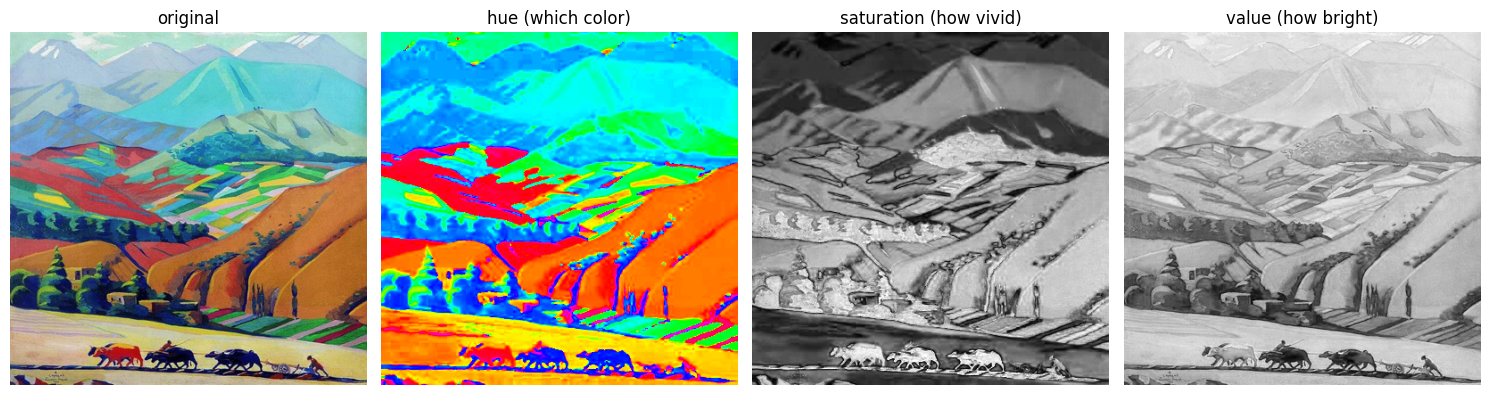

In [13]:
from matplotlib.colors import rgb_to_hsv        # noqa: E402  (kept next to the section that uses it)

hsv = rgb_to_hsv(arr / 255.0)                   # (H, W, 3), each channel in [0, 1]
hue, sat, val = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title, cmap in [
    (axes[0], arr, "original", None),
    (axes[1], hue, "hue (which color)", "hsv"),
    (axes[2], sat, "saturation (how vivid)", "gray"),
    (axes[3], val, "value (how bright)", "gray"),
]:
    ax.imshow(img, cmap=cmap, vmin=None if cmap is None else 0, vmax=None if cmap is None else 1)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hsv_channels.png"), dpi=120, bbox_inches="tight")
plt.show()

### Trap 1: hue is an angle, and k-means does not know that

Hue wraps around. `0.99` and `0.01` are both **red** — they are neighbours on the color wheel —
but plain Euclidean distance says they are `0.98` apart, which is as far apart as two numbers in
$[0, 1]$ can be. The reddest pixels in the painting sit on both sides of that seam.

### Trap 2: hue is meaningless when there is no color

At zero saturation there *is* no hue. Grey is grey. Whatever number the conversion produces for
a near-grey pixel is an artifact of rounding, and feeding it to a distance calculation scatters
your greys around the wheel at random.

In [14]:
near_wrap = ((hue.ravel() < 0.04) | (hue.ravel() > 0.96)) & (sat.ravel() > 0.3)
greyish = sat.ravel() < 0.15
print(f"saturated pixels sitting within 0.04 of the hue seam: {near_wrap.mean():6.2%}")
print(f"near-grey pixels whose hue is numerical noise      : {greyish.mean():6.2%}")

saturated pixels sitting within 0.04 of the hue seam:  7.86%
near-grey pixels whose hue is numerical noise      :  5.38%


### The fix: put the cone into Cartesian coordinates

Both traps have the same cure. Stop feeding the angle directly and feed its **position on the
circle** instead, scaled by saturation:

$$\left(s \cdot \cos 2\pi h,\; s \cdot \sin 2\pi h,\; v\right)$$

Now `h = 0.99` and `h = 0.01` land next to each other, because they are next to each other on
the circle. And a grey pixel has `s ≈ 0`, so it collapses onto the axis and its meaningless hue
stops mattering — the encoding handles the second trap for free.

**This is not a color trick.** Any cyclic feature needs it: hour of day, day of year, month,
wind direction, compass bearing. Feed the raw number and your model believes 23:00 and 01:00 are
the two most distant times of day.

In [15]:
h_flat, s_flat, v_flat = hue.ravel(), sat.ravel(), val.ravel()

hsv_naive = np.column_stack([h_flat, s_flat, v_flat])
hsv_cone = np.column_stack([s_flat * np.cos(2 * np.pi * h_flat),
                            s_flat * np.sin(2 * np.pi * h_flat),
                            v_flat])

K_SPACE = 8
spaces = {"RGB": pixels, "HSV (naive)": hsv_naive, "HSV (cone)": hsv_cone}
space_labels = {name: KMeans(n_clusters=K_SPACE, n_init=10, random_state=SEED).fit_predict(F)
                for name, F in spaces.items()}

To compare the three fairly we repaint every partition the same way: each pixel takes the
**mean RGB of its cluster's members**. Only the grouping differs, not how we render it.

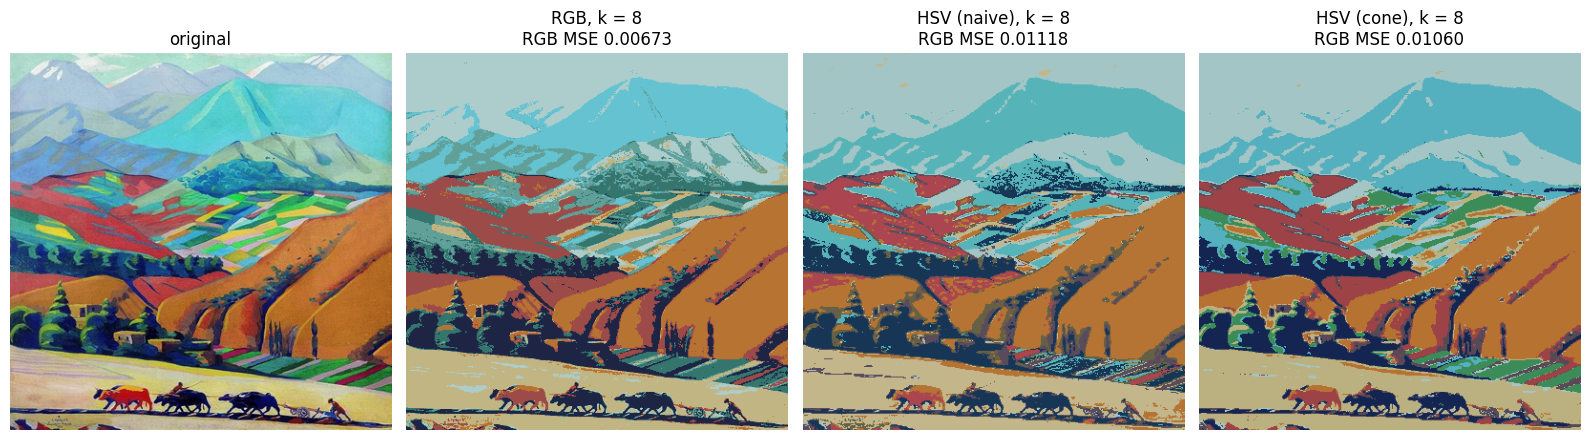

In [16]:
def repaint(lab):
    out = np.zeros_like(pixels)
    for c in range(lab.max() + 1):
        m = lab == c
        out[m] = pixels[m].mean(axis=0)
    return out


quant_by_space = {name: repaint(lab) for name, lab in space_labels.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
axes[0].imshow(arr)
axes[0].set_title("original")
axes[0].axis("off")
for ax, (name, out) in zip(axes[1:], quant_by_space.items()):
    mse = ((out - pixels) ** 2).mean()
    ax.imshow(out.reshape(H, W, C))
    ax.set_title(f"{name}, k = {K_SPACE}\nRGB MSE {mse:.5f}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hsv_space_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

### Did the seam actually break it?

Take the two ends of the wrap — pixels with hue below `0.02` and pixels with hue above `0.98`.
Every one of them is red. A good partition puts them in the same clusters. Here is how much the
two groups' cluster distributions overlap:

In [17]:
lo = (h_flat < 0.02) & (s_flat > 0.3)
hi = (h_flat > 0.98) & (s_flat > 0.3)
print(f"pixels with hue < 0.02: {lo.sum():,}     pixels with hue > 0.98: {hi.sum():,}"
      f"     (all of them red)\n")
for name, lab in space_labels.items():
    a = np.bincount(lab[lo], minlength=K_SPACE) / lo.sum()
    b = np.bincount(lab[hi], minlength=K_SPACE) / hi.sum()
    print(f"  {name:14s} same-cluster overlap {np.minimum(a, b).sum():6.1%}")

pixels with hue < 0.02: 2,685     pixels with hue > 0.98: 6,020     (all of them red)

  RGB            same-cluster overlap  93.5%
  HSV (naive)    same-cluster overlap   0.1%
  HSV (cone)     same-cluster overlap  97.3%


Naive HSV scores essentially **zero**. Not "worse" — it puts almost none of the reds on one side
of the seam into the same cluster as the reds on the other side, because in its distance metric
they are opposite ends of the space. The cone encoding fixes it completely, and plain RGB never
had the problem in the first place: RGB has no angles in it.

### So which space should you quantize in?

Two different questions with two different answers, which is the point.

In [18]:
print(f"{'space':14s} {'RGB MSE':>9s}   {'hue coherence':>14s}")
for name, lab in space_labels.items():
    mse = ((quant_by_space[name] - pixels) ** 2).mean()
    # S-weighted circular resultant: 1.0 = every pixel in the cluster shares one hue
    coherence = []
    for c in range(K_SPACE):
        m = lab == c
        if s_flat[m].sum() < 1e-9:
            continue
        r = np.abs((s_flat[m] * np.exp(2j * np.pi * h_flat[m])).sum()) / s_flat[m].sum()
        coherence.append(r)
    print(f"  {name:14s} {mse:9.5f}   {np.mean(coherence):14.3f}")

space            RGB MSE    hue coherence
  RGB              0.00673            0.898
  HSV (naive)      0.01118            0.866
  HSV (cone)       0.01060            0.918


- **If you want the image back**, cluster in **RGB**. It wins on reconstruction error by a wide
  margin, and that is not a surprise: MSE is measured in RGB, and k-means minimises squared
  distance in whatever space you hand it. Optimise the thing you are graded on.
- **If you want a coherent palette** — all the reds together, all the blues together, regardless
  of light and shade — cluster in **cone-encoded HSV**. It produces the most hue-consistent
  clusters of the three, which is exactly what HSV was supposed to buy you.
- **Naive HSV loses at both.** It is worse than RGB at reconstruction *and* worse than RGB at
  hue coherence, which is a remarkable thing for a color space designed around hue. The circular
  seam costs it more than the representation gains it.

The general lesson is the one from the lecture's very first frame: **k-means has no idea what
your features mean.** It measures Euclidean distance in the space you give it. Choosing that
space, and encoding the features so that distance means what you think it means, is your job and
not the algorithm's.

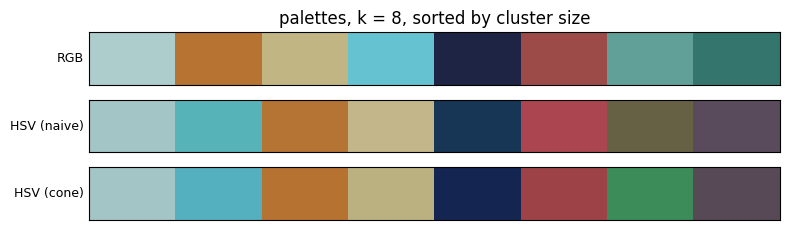

In [19]:
palettes = {}
for name, lab in space_labels.items():
    order = np.argsort(-np.bincount(lab, minlength=K_SPACE))
    palettes[name] = np.array([pixels[lab == c].mean(axis=0) for c in order])

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 2.4))
for ax, (name, pal) in zip(axes, palettes.items()):
    ax.imshow(pal[np.newaxis, :, :], aspect="auto")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
axes[0].set_title(f"palettes, k = {K_SPACE}, sorted by cluster size")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hsv_palettes.png"), dpi=120, bbox_inches="tight")
plt.show()

## 11. Quantize the light, not the numbers

Everything above clustered the numbers stored in the JPEG. Those numbers are **gamma-encoded**:
pixel value 128 does not carry half the light of 255, it carries about 21.6% of it.

That matters here more than anywhere else, because of what a centroid *is*:

> A k-means centroid is the **mean of its members**. Averaging gamma-encoded values does not
> average the light those values carry.

Take the extreme case. A cluster holding pure black and pure white gets the centroid
$(0 + 255)/2 = 127.5$ — a colour that emits 21.6% of the light. The honest average of "no light"
and "all the light" is half the light, which is stored as **188**, not 128.

So every palette above is biased *dark*, and it is not a rounding error. Let us measure it, then
fix it.

In [20]:
# sRGB transfer function (IEC 61966-2-1). "linear" = actual light; "sRGB" = what the file stores.
def srgb_to_linear(s):
    return np.where(s <= 0.04045, s / 12.92, ((s + 0.055) / 1.055) ** 2.4)


def linear_to_srgb(u):
    return np.where(u <= 0.0031308, u * 12.92, 1.055 * u ** (1 / 2.4) - 0.055)


# sanity: the round trip must be exact before we trust anything measured with it
probe = np.linspace(0, 1, 1001)
assert np.abs(linear_to_srgb(srgb_to_linear(probe)) - probe).max() < 1e-12

print(f"pixel 128 emits {srgb_to_linear(np.array(128/255)):.4f} of the light of pixel 255")
print(f"half the light of pixel 255 is stored as pixel "
      f"{255*linear_to_srgb(np.array(0.5)):.1f}\n")

# the black + white cluster, both ways
naive = (0.0 + 1.0) / 2                                  # average the stored numbers
correct = float(linear_to_srgb((srgb_to_linear(np.array(0.0))
                                + srgb_to_linear(np.array(1.0))) / 2))
print(f"cluster {{black, white}} -> centroid as stored : {naive*255:.1f}  "
      f"(emits {srgb_to_linear(np.array(naive)):.1%} of full light)")
print(f"cluster {{black, white}} -> centroid as light  : {correct*255:.1f}  "
      f"(emits {srgb_to_linear(np.array(correct)):.1%} of full light)")

pixel 128 emits 0.2159 of the light of pixel 255
half the light of pixel 255 is stored as pixel 187.5

cluster {black, white} -> centroid as stored : 127.5  (emits 21.4% of full light)
cluster {black, white} -> centroid as light  : 187.5  (emits 50.0% of full light)


### The experiment

Quantize twice at every `k`:

* **as stored** — cluster `pixels` directly (what sections 3–10 did);
* **as light** — linearize first, cluster the light, average the light, then re-encode.

Judge both by the light they actually emit, because that is what leaves the screen. Two numbers:
the **mean-light error** (did the picture get darker?) and the **reconstruction error measured in
linear light** (is it closer to the original?).

In [21]:
lin = srgb_to_linear(pixels)          # the same image, as light instead of as stored numbers
rows = []

for k in k_values:
    # (a) cluster the stored numbers - the naive route
    km_srgb = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(pixels)
    recon_srgb = km_srgb.cluster_centers_[km_srgb.labels_]

    # (b) cluster the light - the honest route
    km_lin = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(lin)
    recon_lin = km_lin.cluster_centers_[km_lin.labels_]

    # judge BOTH in linear light
    light_true = lin.mean()
    light_srgb = srgb_to_linear(recon_srgb).mean()
    light_lin = recon_lin.mean()
    rows.append(dict(
        k=k,
        light_err_srgb=(light_srgb / light_true - 1) * 100,
        light_err_lin=(light_lin / light_true - 1) * 100,
        mse_srgb=((srgb_to_linear(recon_srgb) - lin) ** 2).mean(),
        mse_lin=((recon_lin - lin) ** 2).mean(),
        img_srgb=(recon_srgb.reshape(H, W, C) * 255).round().astype(np.uint8),
        img_lin=(linear_to_srgb(recon_lin).reshape(H, W, C) * 255).round().astype(np.uint8),
    ))

print(f"{'k':>3}  {'light err (as stored)':>21}  {'light err (as light)':>20}"
      f"  {'MSE stored':>11}  {'MSE light':>10}  {'penalty':>8}")
for r in rows:
    print(f"{r['k']:>3}  {r['light_err_srgb']:>20.2f}%  {r['light_err_lin']:>19.2f}%"
          f"  {r['mse_srgb']:>11.6f}  {r['mse_lin']:>10.6f}"
          f"  {(r['mse_srgb']/r['mse_lin']-1)*100:>7.1f}%")

  k  light err (as stored)  light err (as light)   MSE stored   MSE light   penalty
  2                -10.76%                -0.00%     0.027932    0.025523      9.4%
  4                 -4.80%                -0.03%     0.015150    0.012314     23.0%
  8                 -2.49%                -0.03%     0.007271    0.005934     22.5%
 16                 -1.38%                -0.00%     0.004159    0.003066     35.7%
 32                 -0.77%                -0.01%     0.002241    0.001776     26.2%


Two things fall out, and they are worth stating separately.

**The bias is real and it is one-directional.** Quantizing the stored numbers always loses light —
never gains it. At `k = 2` the image comes out over **10%** too dark. That is not subtle; it is a
visibly different picture.

**It shrinks as `k` grows.** With more clusters each one spans a narrower range of brightness, and
over a narrow range the gamma curve is nearly straight — so the average of the numbers and the
average of the light nearly agree. The error is worst exactly where compression is most aggressive.

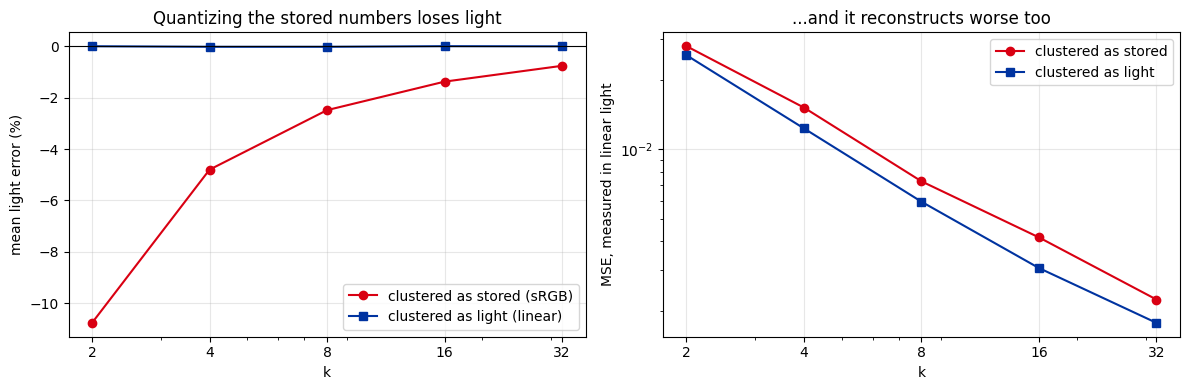

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot([r["k"] for r in rows], [r["light_err_srgb"] for r in rows],
        marker="o", color=ARM_RED, label="clustered as stored (sRGB)")
ax.plot([r["k"] for r in rows], [r["light_err_lin"] for r in rows],
        marker="s", color=ARM_BLUE, label="clustered as light (linear)")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="k", ylabel="mean light error (%)", xscale="log",
       title="Quantizing the stored numbers loses light")
ax.set_xticks(k_values); ax.set_xticklabels(k_values)
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([r["k"] for r in rows], [r["mse_srgb"] for r in rows],
        marker="o", color=ARM_RED, label="clustered as stored")
ax.plot([r["k"] for r in rows], [r["mse_lin"] for r in rows],
        marker="s", color=ARM_BLUE, label="clustered as light")
ax.set(xlabel="k", ylabel="MSE, measured in linear light", xscale="log", yscale="log",
       title="...and it reconstructs worse too")
ax.set_xticks(k_values); ax.set_xticklabels(k_values)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "gamma_quantization.png"), dpi=120, bbox_inches="tight")
plt.show()

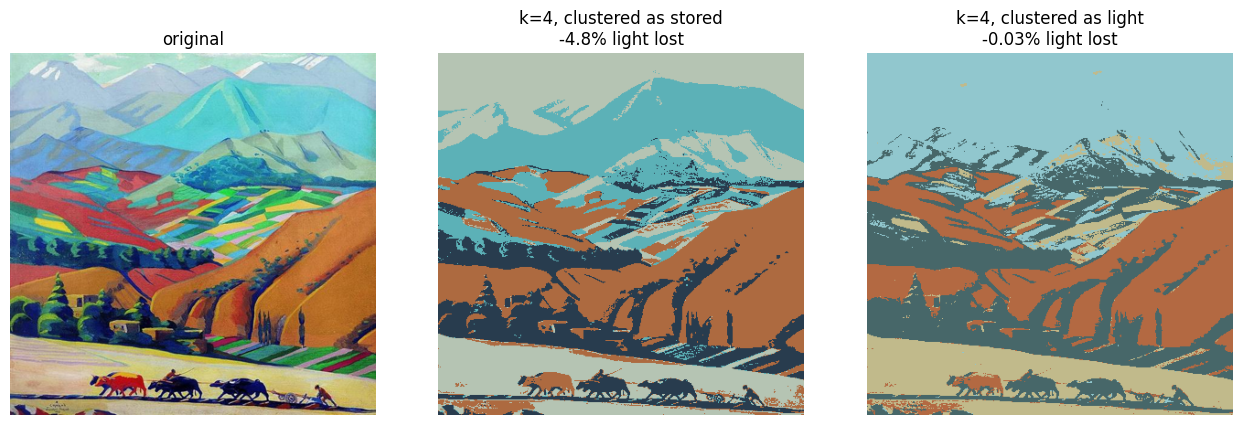

In [23]:
# See it. At k = 4 the difference is not a subtlety.
show_k = 4
r = next(r for r in rows if r["k"] == show_k)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, im, t in zip(axes,
                     [arr, r["img_srgb"], r["img_lin"]],
                     ["original",
                      f"k={show_k}, clustered as stored\n{r['light_err_srgb']:.1f}% light lost",
                      f"k={show_k}, clustered as light\n{r['light_err_lin']:.2f}% light lost"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "gamma_side_by_side.png"), dpi=120, bbox_inches="tight")
plt.show()

### Why one of them is exactly right

The task asked for one line of algebra rather than an experiment, and here it is.

Cluster $C$ has members with light values $u_i$. Clustering **in linear light** sets the centroid to
$\bar{u} = \frac{1}{|C|}\sum_{i \in C} u_i$, so the light the cluster emits after quantization is

$$|C| \cdot \bar{u} = \sum_{i \in C} u_i$$

which is exactly the light it emitted before. Every cluster preserves its own light, so the whole
image does. **The mean-light error is zero by construction, not by luck** — and it holds for any
`k`, any image, any initialization.

Clustering the stored values gives the centroid $\overline{s}$, and the light that emits is
$f(\overline{s})$ where $f$ is the sRGB curve. What we wanted was $\overline{f(s)}$. Since $f$ is
**convex** on $[0,1]$, Jensen's inequality gives $f(\overline{s}) \le \overline{f(s)}$: the
quantized image can only come out darker, never lighter. That is the one-directional bias in the
table above, and it is why no amount of re-running changes its sign.

The table shows the linear route at about $-0.03\%$ rather than a clean zero. That is not the
mathematics failing — it is `sklearn`, which stops when the centroids move less than `tol` and so
returns centroids from one iteration before the final assignment. Recompute them as exact means of
the final labels and the guarantee reappears:

In [24]:
km = KMeans(n_clusters=8, n_init=10, random_state=SEED).fit(lin)

as_returned = km.cluster_centers_[km.labels_].mean()
exact = np.stack([lin[km.labels_ == c].mean(axis=0) for c in range(8)])
recomputed = exact[km.labels_].mean()

print(f"true mean light            {lin.mean():.8f}")
print(f"sklearn's centroids        {as_returned:.8f}   ({(as_returned/lin.mean()-1)*100:+.4f}%)")
print(f"centroids recomputed exactly {recomputed:.8f}   ({(recomputed/lin.mean()-1)*100:+.4f}%)")
print("\nThe residual was sklearn's convergence tolerance, not the method.")

true mean light            0.30806730
sklearn's centroids        0.30798588   (-0.0264%)
centroids recomputed exactly 0.30806730   (-0.0000%)

The residual was sklearn's convergence tolerance, not the method.


## 12. A palette you can actually buy

A centroid is an **average**, and an average of real things is usually not itself a real thing. The
palette entries above are colours that in general appear **nowhere in the image**.

That is fine when the output is a screen. It stops being fine the moment the palette has to be
physically realizable: paint, embroidery thread, print inks, or a device with a fixed colour table.
Then you cannot ask for "the average of these pixels" — you have to pick one of the colours you
actually have.

First, confirm the problem exists.

In [25]:
from scipy.spatial.distance import cdist   # noqa: E402  (kept next to the section using it)

K_PAL = 8
km_pal = KMeans(n_clusters=K_PAL, n_init=10, random_state=SEED).fit(pixels)
present = np.unique(pixels, axis=0)        # every colour that actually occurs in the image

gap = cdist(km_pal.cluster_centers_, present).min(axis=1) * 255
print(f"the image contains {len(present):,} distinct colours\n")
print("distance from each centroid to the nearest colour that really occurs (0-255 units):")
print("  " + "  ".join(f"{g:5.2f}" for g in gap))
print(f"\ncentroids that ARE a real colour from the image: "
      f"{(gap < 1e-9).sum()} of {K_PAL}")

the image contains 124,841 distinct colours

distance from each centroid to the nearest colour that really occurs (0-255 units):
   1.58   1.07   1.04   2.63   1.08   2.30   1.25   1.51

centroids that ARE a real colour from the image: 0 of 8


None of them. Now **k-medoids**: same alternating loop as k-means, but the centre of a cluster must
be one of its own members, so the palette is real by construction.

`scikit-learn` has no k-medoids, so here is the loop. The only trick is that evaluating every
candidate against every member is $O(n^2)$ — restrict both to random subsamples and it finishes in
seconds without changing the answer materially.

In [26]:
def kmedoids(X, k, seed=SEED, n_candidates=2000, max_iter=25):
    '''Alternating k-medoids. Returns (medoids, labels). Medoids are real rows of X.'''
    rng = np.random.default_rng(seed)
    pool = X[rng.choice(len(X), min(n_candidates, len(X)), replace=False)]
    medoids = pool[rng.choice(len(pool), k, replace=False)].copy()

    for _ in range(max_iter):
        labels = cdist(X, medoids).argmin(axis=1)
        moved = False
        for c in range(k):
            members = X[labels == c]
            if len(members) == 0:
                continue
            # candidates: real member colours. cost: total distance to the rest of the cluster.
            cand = members if len(members) <= 300 else \
                members[rng.choice(len(members), 300, replace=False)]
            ref = members if len(members) <= 3000 else \
                members[rng.choice(len(members), 3000, replace=False)]
            best = cand[cdist(cand, ref).sum(axis=1).argmin()]
            if not np.allclose(best, medoids[c]):
                medoids[c], moved = best, True
        if not moved:
            break

    return medoids, cdist(X, medoids).argmin(axis=1)


medoids, med_labels = kmedoids(pixels, K_PAL)

real = np.array([np.any(np.all(np.isclose(present, m), axis=1)) for m in medoids])
mse_centroid = ((km_pal.cluster_centers_[km_pal.labels_] - pixels) ** 2).mean()
mse_medoid = ((medoids[med_labels] - pixels) ** 2).mean()

print(f"medoid palette entries that are real pixels: {real.sum()} of {K_PAL}\n")
print(f"MSE with centroids {mse_centroid:.6f}")
print(f"MSE with medoids   {mse_medoid:.6f}   ({(mse_medoid/mse_centroid-1)*100:+.1f}%)")
print("\nThat percentage is the price of a palette you can actually mix.")

medoid palette entries that are real pixels: 8 of 8

MSE with centroids 0.006727
MSE with medoids   0.007243   (+7.7%)

That percentage is the price of a palette you can actually mix.


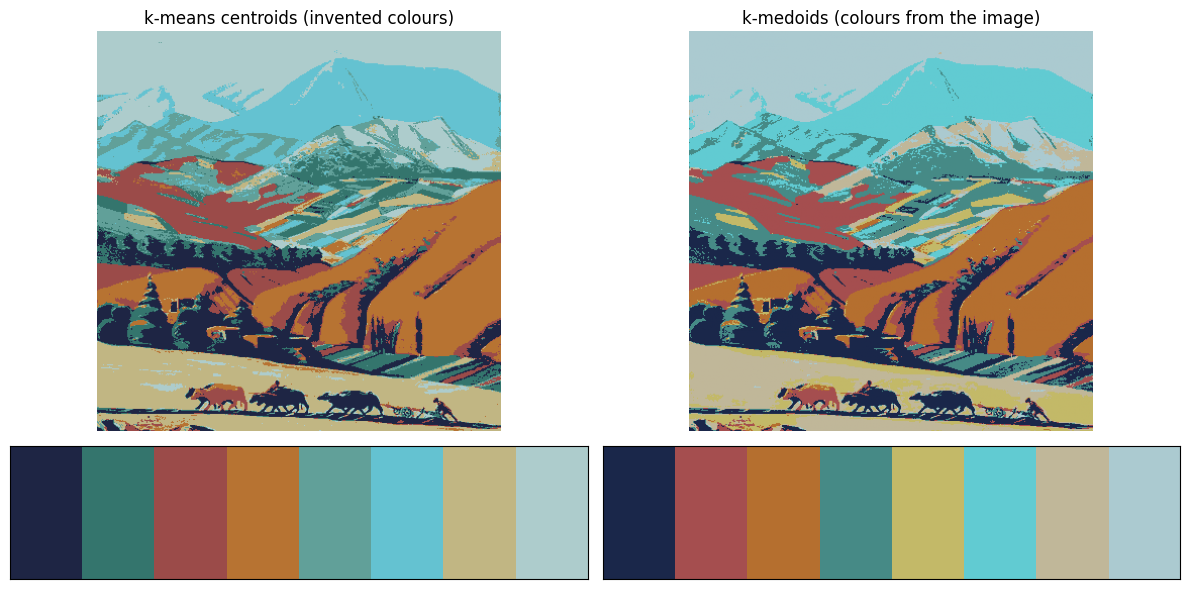

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         gridspec_kw={"height_ratios": [3, 1]})

for col, (img_pixels, name) in enumerate([
        (km_pal.cluster_centers_[km_pal.labels_], f"k-means centroids (invented colours)"),
        (medoids[med_labels], f"k-medoids (colours from the image)")]):
    axes[0, col].imshow(img_pixels.reshape(H, W, C))
    axes[0, col].set_title(name)
    axes[0, col].axis("off")

for col, pal in enumerate([km_pal.cluster_centers_, medoids]):
    order = np.argsort(pal.sum(axis=1))
    axes[1, col].imshow(pal[order][np.newaxis, :, :], aspect="auto")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "medoid_palette.png"), dpi=120, bbox_inches="tight")
plt.show()

## 13. Nested palettes

Suppose the image must render **progressively** — 8 colours first, refining to 16 and then 32 as
more data arrives — or one palette has to degrade gracefully onto a weaker device. Then you want
the 8-colour palette to be a **merge** of the 16-colour one: every fine group entirely inside one
coarse group.

Does k-means give you that? Test it rather than assuming.

In [28]:
from scipy.cluster.hierarchy import linkage, fcluster   # noqa: E402


def is_nested(coarse_labels, fine_labels):
    '''True if every fine cluster lies entirely within a single coarse cluster.'''
    return all(len(np.unique(coarse_labels[fine_labels == c])) == 1
               for c in np.unique(fine_labels))


sub_idx = np.random.default_rng(SEED).choice(len(pixels), 4000, replace=False)
sub = pixels[sub_idx]

km8 = KMeans(n_clusters=8, n_init=10, random_state=SEED).fit_predict(sub)
km16 = KMeans(n_clusters=16, n_init=10, random_state=SEED).fit_predict(sub)
print(f"k-means, 8 vs 16 nested? {is_nested(km8, km16)}")

Z = linkage(sub, method="ward")               # ONE tree, cut at three heights
cuts = {k: fcluster(Z, t=k, criterion="maxclust") for k in (8, 16, 32)}
print(f"Ward,  8 vs 16 nested? {is_nested(cuts[8], cuts[16])}")
print(f"Ward, 16 vs 32 nested? {is_nested(cuts[16], cuts[32])}")

k-means, 8 vs 16 nested? False


Ward,  8 vs 16 nested? True
Ward, 16 vs 32 nested? True


k-means gives you three unrelated answers: its `k = 8` solution is not a coarsening of its `k = 16`
solution, because each run optimises its own objective from its own initialization. Nothing ties
them together.

Ward gives nesting **for free**, because there is only one object: a tree. Cutting it at 8 and at
16 is reading the same merge history at two heights, so containment is structural, not a lucky
outcome. That is the whole difference between *partitioning* and *hierarchical* clustering, and
this is a task where it is worth real money.

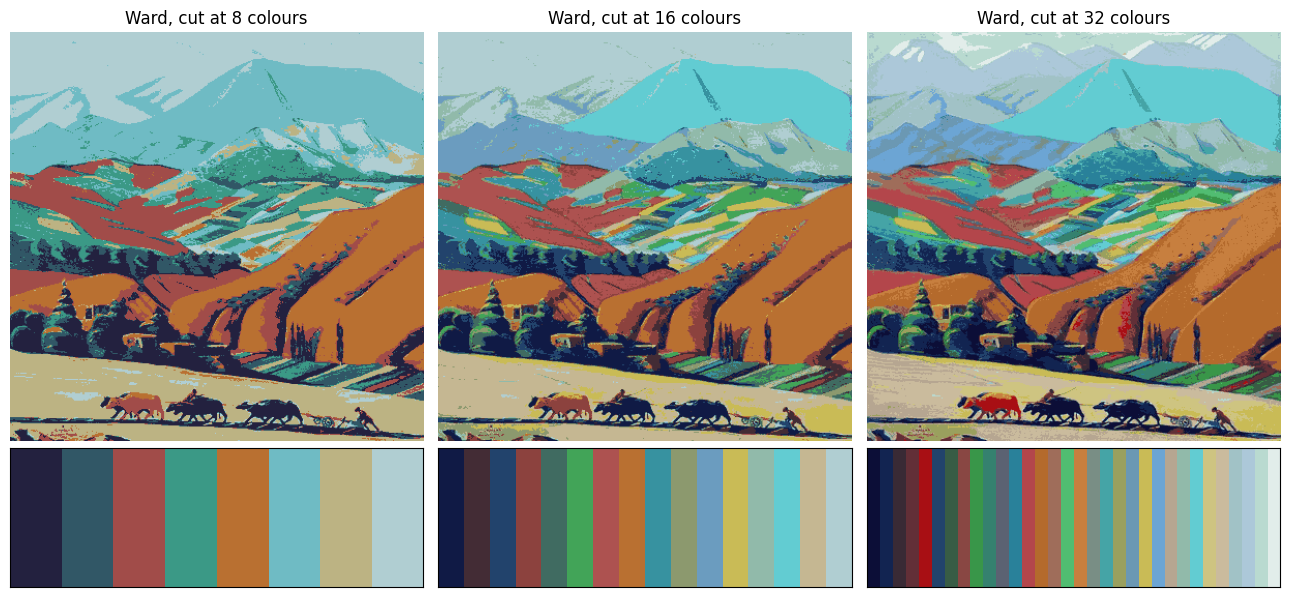

In [29]:
# Build the three nested palettes and paint the full image with each.
fig, axes = plt.subplots(2, 3, figsize=(13, 6),
                         gridspec_kw={"height_ratios": [3, 1]})

for col, k in enumerate((8, 16, 32)):
    lab = cuts[k]
    centres = np.stack([sub[lab == c].mean(axis=0) for c in np.unique(lab)])
    full = centres[cdist(pixels, centres).argmin(axis=1)]     # assign every pixel to a leaf
    axes[0, col].imshow(full.reshape(H, W, C))
    axes[0, col].set_title(f"Ward, cut at {k} colours")
    axes[0, col].axis("off")

    order = np.argsort(centres.sum(axis=1))
    axes[1, col].imshow(centres[order][np.newaxis, :, :], aspect="auto")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nested_palettes.png"), dpi=120, bbox_inches="tight")
plt.show()

## 14. Let the data choose the number of colours

Every method so far was handed a `k`. Density-based clustering does not need one: it finds regions
where points are packed together and calls everything else **noise**. So — how many colours does the
data itself think are in this painting?

In [30]:
from sklearn.cluster import DBSCAN, HDBSCAN   # noqa: E402

sub2 = pixels[np.random.default_rng(SEED).choice(len(pixels), 20000, replace=False)]

print(f"{'setting':>34}  {'clusters':>8}  {'noise':>7}")
results = {}
for eps in (0.02, 0.05, 0.10):
    lab = DBSCAN(eps=eps, min_samples=20).fit_predict(sub2)
    n = len(set(lab)) - (1 if -1 in lab else 0)
    results[f"DBSCAN eps={eps}"] = (lab, n)
    print(f"{'DBSCAN eps=' + format(eps, '.2f'):>34}  {n:>8}  {(lab == -1).mean():>6.1%}")

lab_h = HDBSCAN(min_cluster_size=200).fit_predict(sub2)
n_h = len(set(lab_h)) - (1 if -1 in lab_h else 0)
results["HDBSCAN"] = (lab_h, n_h)
print(f"{'HDBSCAN min_cluster_size=200':>34}  {n_h:>8}  {(lab_h == -1).mean():>6.1%}")

                           setting  clusters    noise
                   DBSCAN eps=0.02        14   51.4%


                   DBSCAN eps=0.05         5    5.2%


                   DBSCAN eps=0.10         1    0.0%


      HDBSCAN min_cluster_size=200         7   39.3%


Look at what `eps` does. Move it by a factor of five and the answer goes from 14 colours to 1.
There is no setting that is obviously right, and the one that returns a sensible *number* of
clusters throws away half the image as noise.

And now the problem k-means never poses: **noise points have no centroid.** DBSCAN has told us
these pixels belong to no cluster. They still have to be painted something.

The defensible choice is to assign each noise pixel to the nearest cluster's mean colour — we are
compressing, not detecting outliers, and every pixel must get a colour. Worth being explicit that
this is a decision the algorithm refused to make for us.

DBSCAN found 5 clusters; painting every pixel with the nearest cluster mean
  MSE, DBSCAN palette : 0.037348
  MSE, k-means k=5    : 0.010325


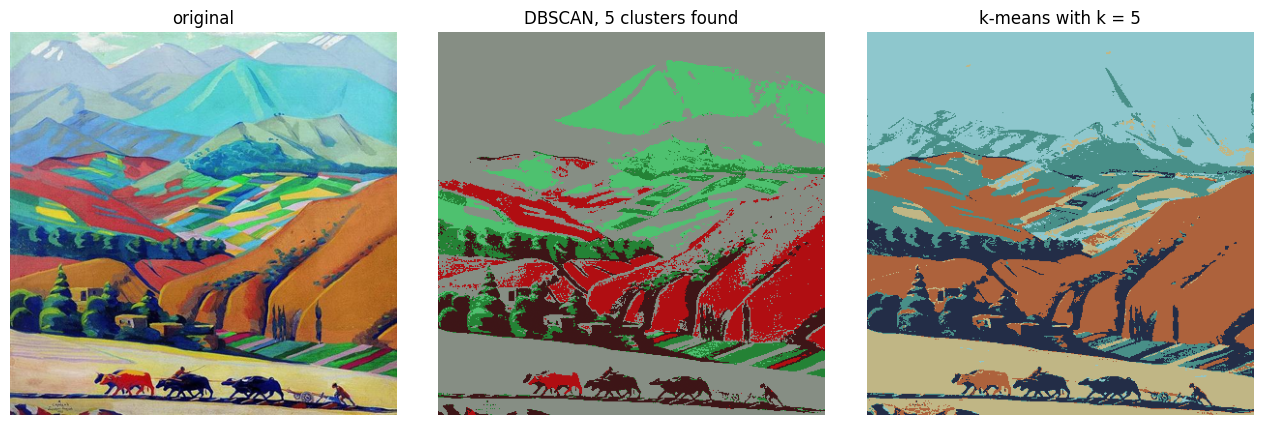

In [31]:
lab, n_found = results["DBSCAN eps=0.05"]
centres = np.stack([sub2[lab == c].mean(axis=0) for c in range(n_found)])
full = centres[cdist(pixels, centres).argmin(axis=1)]        # noise included, by nearest centre

km_same = KMeans(n_clusters=n_found, n_init=10, random_state=SEED).fit(pixels)
recon_km = km_same.cluster_centers_[km_same.labels_]

print(f"DBSCAN found {n_found} clusters; painting every pixel with the nearest cluster mean")
print(f"  MSE, DBSCAN palette : {((full - pixels) ** 2).mean():.6f}")
print(f"  MSE, k-means k={n_found}    : {((recon_km - pixels) ** 2).mean():.6f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, im, t in zip(axes, [arr, full.reshape(H, W, C), recon_km.reshape(H, W, C)],
                     ["original", f"DBSCAN, {n_found} clusters found",
                      f"k-means with k = {n_found}"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dbscan_palette.png"), dpi=120, bbox_inches="tight")
plt.show()

**So can density answer "how many colours are in this image"?** No — and the reason is a property of
photographs, not a weakness of DBSCAN.

Density-based clustering separates groups by finding **empty space** between them. A photograph's
colour cloud has almost none: it is one connected ridge running from shadow to highlight, because
every real surface appears at every level of illumination, and those shades form a continuous path
through the colour cube. There is no gap to cut. Widen `eps` and everything fuses into one cluster;
narrow it and you are not finding colours, you are finding whichever spots happen to be densest,
and half the image falls off the edge as noise.

k-means succeeds here for the same reason it looked crude in the lecture: it does not ask whether
the clusters are *real*. Being told "give me exactly 8 colours" is not a limitation for this task,
it is the actual specification.

## 15. Bonus --- `MiniBatchKMeans` on the full-resolution image

`MiniBatchKMeans` updates centroids from small random batches, so it quantizes the full image far faster than plain k-means, for a tiny quality cost.

full-res pixels: 363,000


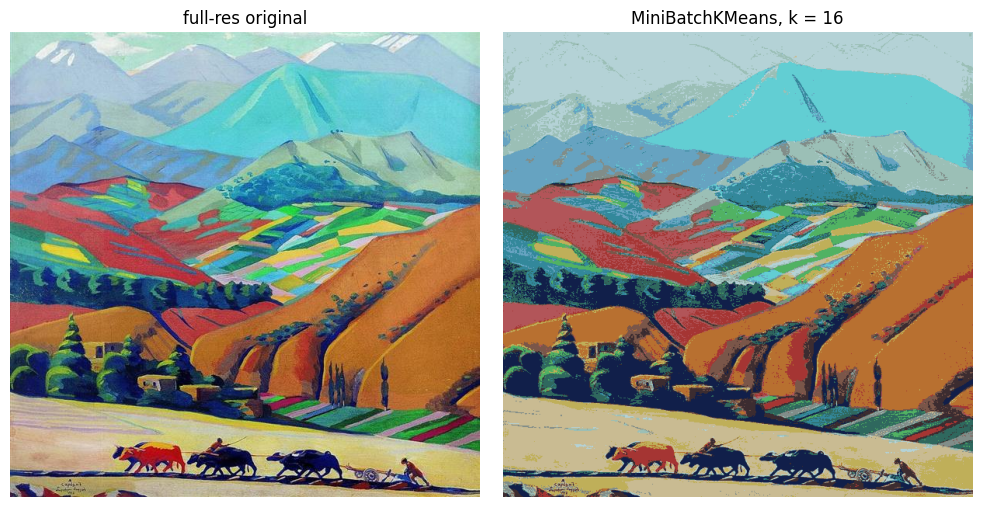

In [32]:
full = np.asarray(Image.open(IMG_PATH).convert("RGB"))
full_pixels = full.reshape(-1, 3).astype(np.float64) / 255.0
print(f"full-res pixels: {full_pixels.shape[0]:,}")

mbk = MiniBatchKMeans(n_clusters=16, random_state=SEED, n_init=3, batch_size=2048)
labels = mbk.fit_predict(full_pixels)
full_quant = (mbk.cluster_centers_[labels].reshape(full.shape) * 255).round().astype(np.uint8)
Image.fromarray(full_quant).save(os.path.join(OUT_DIR, "fullres_minibatch_k16.jpg"), quality=95)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(full);       ax[0].set_title("full-res original"); ax[0].axis("off")
ax[1].imshow(full_quant); ax[1].set_title("MiniBatchKMeans, k = 16"); ax[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fullres_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

In [33]:
print("Files written to out/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f, f"({os.path.getsize(os.path.join(OUT_DIR, f))/1024:,.0f} KB)")

Files written to out/:
   banding.png (279 KB)
   banding_two_images.png (378 KB)
   comparison_grid.png (763 KB)
   dbscan_palette.png (693 KB)
   elbow_silhouette.png (45 KB)
   fullres_comparison.png (960 KB)
   fullres_minibatch_k16.jpg (168 KB)
   gamma_quantization.png (73 KB)
   gamma_side_by_side.png (592 KB)
   hsv_channels.png (987 KB)
   hsv_palettes.png (12 KB)
   hsv_space_comparison.png (836 KB)
   indexed_k02.png (4 KB)
   indexed_k04.png (9 KB)
   indexed_k08.png (14 KB)
   indexed_k16.png (21 KB)
   indexed_k32.png (29 KB)
   lc_cluster_spectra.png (77 KB)
   lc_contingency.png (51 KB)
   lc_elbow_silhouette.png (47 KB)
   lc_feature_sets.png (194 KB)
   lc_gmm_confidence.png (904 KB)
   lc_indices.png (872 KB)
   lc_kdistance.png (22 KB)
   lc_kmeans_map.png (1,076 KB)
   lc_true_false_colour.png (1,832 KB)
   lc_worldcover.png (1,041 KB)
   medoid_palette.png (372 KB)
   nested_palettes.png (628 KB)
   original.png (284 KB)
   palette_k16.png (4 KB)
   rgb_scatter.ht

## Conclusion

- Treating pixels as points in RGB space turns compression into a **clustering** problem: k-means finds `k` representative colors (see the 3D scatter) and we repaint the image with them.
- Inertia falls smoothly with `k`, while the silhouette only **declines** (it would pick `k = 2`) --- so for quantization `k` is a **quality/size trade-off**, not a natural cluster count. Around `k = 16-32` the result looks close to the original.
- The payoff is real, not just theory: saved as **indexed PNGs** the files shrink steeply as `k` drops --- in fact *more* than the `~24 / ceil(log2 k)` raw-index estimate, because PNG also losslessly compresses (DEFLATE) the index stream; reconstruction MSE shrinks as `k` grows.
- At very small `k` the cost is visible as **banding** in smooth regions.
- All figures and images are saved under **`out/`**.